# Path finding 

In [ ]:
"""
SHORTEST PATH ON ROAD MASK  —  A* Implementation
Input : binary road mask + original image
Output: shortest path drawn on overlay image

Usage:
  1. Set START_POINT and END_POINT (pixel x,y), OR
  2. Run Cell 2 to click points interactively

"""

'\nSHORTEST PATH ON ROAD MASK  —  A* Implementation\n=================================================\nInput : binary road mask + original image\nOutput: shortest path drawn on overlay image\n\nUsage:\n  1. Set START_POINT and END_POINT (pixel x,y), OR\n  2. Run Cell 2 to click points interactively\n\nNo external graph libraries needed — pure numpy + heapq.\n'

In [2]:

import cv2
import numpy as np
import heapq
import os
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, remove_small_objects


In [ ]:
import json
import numpy as np

with open("homographies.json") as f:
    H_save = json.load(f)

In [ ]:


# INPUTS 
MASK_PATH   = "DeepGlobe_Dataset/train/17193_mask.png"
IMAGE_PATH  = "DeepGlobe_Dataset/train/17193_sat.jpg"
OUTPUT_DIR  = "output/"

# Set pixel coordinates (x, y) - or leave None and use click tool
START_POINT = None    # e.g. (150, 400)
END_POINT   = None    # e.g. (900, 250)

#os.makedirs(OUTPUT_DIR, exist_ok=True)


Loaded  1024x1024  road=14.1%


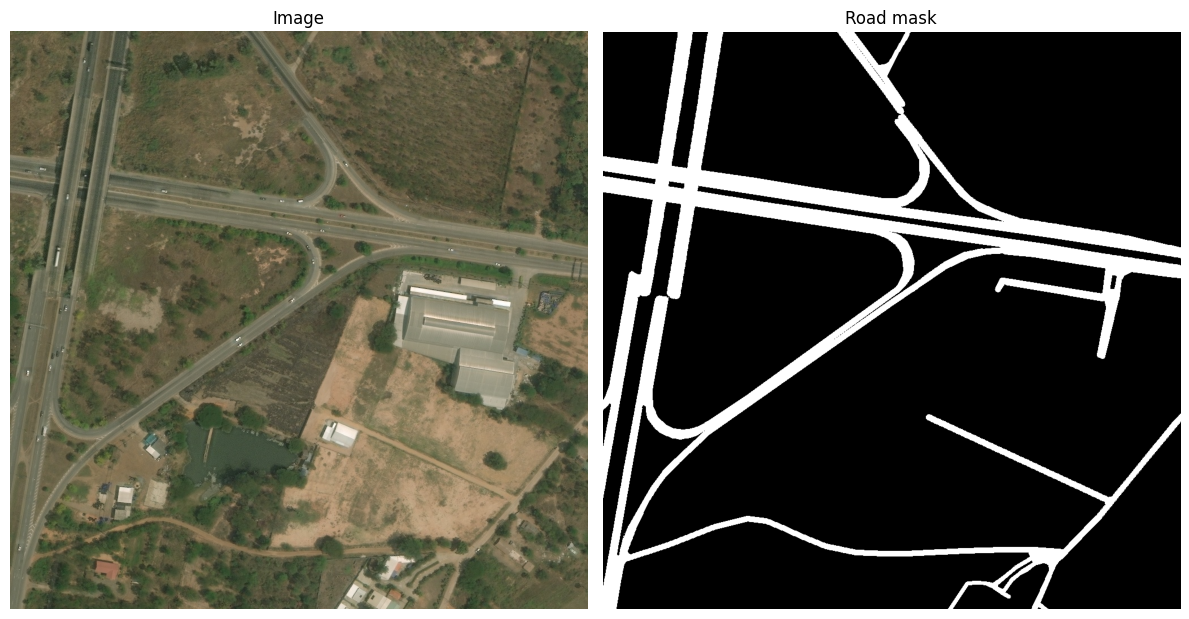

In [11]:
# Load
mask = cv2.imread(MASK_PATH, cv2.IMREAD_GRAYSCALE)
img  = cv2.imread(IMAGE_PATH)
assert mask is not None, f"Cannot read: {MASK_PATH}"
assert img  is not None, f"Cannot read: {IMAGE_PATH}"

if img.shape[:2] != mask.shape[:2]:
    img = cv2.resize(img, (mask.shape[1], mask.shape[0]))

H, W   = mask.shape
binary = (mask > 127).astype(np.uint8)
print(f"Loaded  {W}x{H}  road={binary.mean()*100:.1f}%")

fig, ax = plt.subplots(1,2,figsize=(12,7))
ax[0].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB)); ax[0].set_title("Image"); ax[0].axis("off")
ax[1].imshow(binary*255, cmap='gray');              ax[1].set_title("Road mask"); ax[1].axis("off")
plt.tight_layout(); plt.show()


In [ ]:
def transform_point(pt, H):
    x, y = pt
    p = np.array([x, y, 1])

    p_new = H @ p
    p_new = p_new / p_new[2]

    return int(p_new[0]), int(p_new[1])

In [ ]:
start_fragment = 2
end_fragment   = 5

start_pt = (120, 300)   # on fragment 2
end_pt   = (400, 150)   # on fragment 5

In [ ]:
H_start = np.array(H_save[str(start_fragment)])
H_end   = np.array(H_save[str(end_fragment)])

start_global = transform_point(start_pt, H_start)
end_global   = transform_point(end_pt, H_end)

print("Start:", start_global)
print("End:", end_global)

In [ ]:
# OPTION 1 — OpenCV window click ( if u dont have any specific point)
"""
This opens a native OpenCV window.
Left-click to set START (green dot shown)
Left-click again to set END (red dot shown)
Press Q to confirm and close.
"""
 
def pick_points_opencv(image, mask):
    """
    Opens an OpenCV window for clicking start/end points.
    Returns [(x1,y1), (x2,y2)].
    """
    ov2    = image.copy()
    ov2[mask>127] = (ov2[mask>127].astype(np.float32)*0.35 +
                     np.array([0,200,80],np.float32)*0.65).astype(np.uint8)
 
    # Resize for display if too large
    dh, dw = ov2.shape[:2]
    max_dim = 900
    scale   = 1.0
    if max(dh, dw) > max_dim:
        scale = max_dim / max(dh, dw)
        ov2   = cv2.resize(ov2, (int(dw*scale), int(dh*scale)))
 
    points  = []
    display = ov2.copy()
 
    def mouse_cb(event, x, y, flags, param):
        nonlocal display
        if event == cv2.EVENT_LBUTTONDOWN and len(points) < 2:
            # Scale back to original coordinates
            orig_x = int(x / scale)
            orig_y = int(y / scale)
            points.append((orig_x, orig_y))
 
            color = (0, 255, 0) if len(points)==1 else (50, 50, 255)
            label = "S" if len(points)==1 else "E"
            cv2.circle(display, (x,y), 10, color, -1)
            cv2.circle(display, (x,y), 10, (255,255,255), 2)
            cv2.putText(display, label, (x-6,y+5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
            cv2.imshow("Pick Points — Q to confirm", display)
            print(f"{'START' if len(points)==1 else 'END'} = ({orig_x}, {orig_y})")
 
    cv2.namedWindow("Pick Points — Q to confirm", cv2.WINDOW_NORMAL)
    cv2.setMouseCallback("Pick Points — Q to confirm", mouse_cb)
    cv2.imshow("Pick Points — Q to confirm", display)
 
    print("LEFT CLICK = set start point")
    print("LEFT CLICK again = set end point")
    print("Press Q to confirm and close window")
 
    while True:
        key = cv2.waitKey(20) & 0xFF
        if key == ord('q') or key == ord('Q'):
            break
        if len(points) == 2:
            print("Both points set. Press Q to confirm.")
 
    cv2.destroyAllWindows()
    return points
 
# ── Run Option 3 ─────────────────────────────────────────
print("\nOPTION 3 — Opening OpenCV window...")
print("(If no window appears, use Option 1 hover method instead)")
 
picked = pick_points_opencv(img, binary)
 
if len(picked) == 2:
    START_POINT = picked[0]
    END_POINT   = picked[1]
    print(f"\n✓ Points confirmed:")
    print(f"  START_POINT = {START_POINT}")
    print(f"  END_POINT   = {END_POINT}")
else:
    print(f"Only {len(picked)} point(s) picked. Try again.")
 
 
# AFTER PICKING — paste coordinates here and run path finding 
# START_POINT = (x1, y1)
# END_POINT   = (x2, y2)
 
print(f"\nFinal coordinates:")
print(f"  START_POINT = {START_POINT}")
print(f"  END_POINT   = {END_POINT}")
print("\nNow run the A* cells below.")


OPTION 3 — Opening OpenCV window...
(If no window appears, use Option 1 hover method instead)
LEFT CLICK = set start point
LEFT CLICK again = set end point
Press Q to confirm and close window
START = (134, 11)
END = (494, 339)
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to confirm.
Both points set. Press Q to conf

In [ ]:

# Go to nearest road pixel


def Go_to_road(xy, binary, max_r=100):
    x, y = np.clip(int(xy[0]),0,W-1), np.clip(int(xy[1]),0,H-1)
    if binary[y,x]: return (x,y)
    # BFS to find nearest road pixel
    seen  = {(y,x)}
    queue = [(0,y,x)]
    while queue:
        d,cy,cx = heapq.heappop(queue)
        if d > max_r: break
        for dy,dx in [(-1,0),(1,0),(0,-1),(0,1),
                      (-1,-1),(-1,1),(1,-1),(1,1)]:
            ny,nx = cy+dy, cx+dx
            if (ny,nx) in seen: continue
            if not(0<=ny<H and 0<=nx<W): continue
            seen.add((ny,nx))
            if binary[ny,nx]:
                print(f"  Snapped ({x},{y})→({nx},{ny})")
                return (nx,ny)
            heapq.heappush(queue,(d+(1.414 if dy and dx else 1),ny,nx))
    raise ValueError(f"No road within {max_r}px of {xy}")

start_s = Go_to_road(START_POINT, binary)
end_s   = Go_to_road(END_POINT,   binary)
print(f"Start : {start_s}")
print(f"End   : {end_s}")


Start snapped: (np.int64(134), np.int64(11))
End   snapped: (np.int64(494), np.int64(339))


In [ ]:
# A* on road pixels


def astar(binary, start_xy, end_xy):
    """
    A* on road mask pixels.
    Moves: 8-connected, only on road pixels.
    Cost : 1.0 (axis) or 1.414 (diagonal).
    Heuristic: Euclidean to goal 
    """
    sx,sy = start_xy
    ex,ey = end_xy
    if (sx,sy)==(ex,ey): return [(sx,sy)]

    def h(x,y): return ((x-ex)**2+(y-ey)**2)**0.5

    open_q    = [(h(sx,sy), 0.0, sx, sy)]
    g         = {(sx,sy): 0.0}
    prev      = {}
    closed    = set()

    while open_q:
        f, gc, cx, cy = heapq.heappop(open_q)
        if (cx,cy) in closed: continue
        closed.add((cx,cy))

        if cx==ex and cy==ey:
            path=[]
            node=(ex,ey)
            while node in prev:
                path.append(node); node=prev[node]
            path.append((sx,sy)); path.reverse()
            return path
        
        

        for dy in [-1,0,1]:
            for dx in [-1,0,1]:
                if dy==0 and dx==0: continue
                nx,ny = cx+dx, cy+dy
                if not(0<=nx<W and 0<=ny<H): continue
                if not binary[ny,nx]: continue
                if (nx,ny) in closed: continue
                step = 1.4142 if (abs(dx)+abs(dy)==2) else 1.0
                ng   = gc+step
                if ng < g.get((nx,ny),1e18):
                    g[(nx,ny)]    = ng
                    prev[(nx,ny)] = (cx,cy)
                    heapq.heappush(open_q,(ng+h(nx,ny),ng,nx,ny))
    return []

print("Running A*...")
path = astar(binary, start_s, end_s)

if path:
    path_len = sum(1.414 if abs(path[i][0]-path[i+1][0])+
                             abs(path[i][1]-path[i+1][1])==2
                   else 1.0
                   for i in range(len(path)-1))
    straight = ((end_s[0]-start_s[0])**2+(end_s[1]-start_s[1])**2)**0.5
    print(f"Path found: {len(path)} px  length={path_len:.0f}px  "
          f"straight={straight:.0f}px  detour={path_len/straight:.2f}x")
else:
    print("No path found — start/end may be on disconnected segments.")
    print("Tip: run enforce_topology from road_seg_fixed.py first.")


Running A*...
Path found: 601 px  length=647px  straight=487px  detour=1.33x


In [ ]:
# Skeleton graph A* 

def skeleton_astar(binary, start_xy, end_xy):
    """
    Faster alternative: skeletonize -> sparse graph -> A*.
    Better for large images (>2000px) where pixel A* is slow.
    """
    # Skeletonize
    clean = remove_small_objects(binary.astype(bool), min_size=50)
    skel  = skeletonize(clean).astype(np.uint8)
    pset  = set(map(tuple, np.argwhere(skel>0).tolist()))

    def nbs(y,x):
        return [(y+dy,x+dx) for dy in[-1,0,1] for dx in[-1,0,1]
                if (dy or dx) and (y+dy,x+dx) in pset]

    # Snap to nearest skeleton pixel
    def snap_skel(xy):
        ox,oy = int(xy[0]), int(xy[1])
        ys,xs = np.where(skel>0)
        if len(ys)==0: return None
        d = (ys-oy)**2+(xs-ox)**2
        i = np.argmin(d)
        return (int(ys[i]),int(xs[i]))

    sy0,sx0 = snap_skel(start_xy)
    sy1,sx1 = snap_skel(end_xy)

    def h(y,x): return ((y-sy1)**2+(x-sx1)**2)**0.5

    open_q = [(h(sy0,sx0), 0.0, sy0, sx0)]
    g      = {(sy0,sx0): 0.0}
    prev   = {}
    closed = set()


    while open_q:
        f,gc,cy,cx = heapq.heappop(open_q)
        if (cy,cx) in closed: continue
        closed.add((cy,cx))
        if cy==sy1 and cx==sx1:
            path=[]
            node=(sy1,sx1)
            while node in prev:
                path.append((node[1],node[0]))  # (x,y)
                node=prev[node]
            path.append((sx0,sy0))
            path.reverse()
            return path
        for (ny,nx) in nbs(cy,cx):
            if (ny,nx) in closed: continue
            step = 1.414 if (abs(cy-ny)+abs(cx-nx)==2) else 1.0
            ng   = gc+step
            if ng < g.get((ny,nx),1e18):
                g[(ny,nx)]    = ng
                prev[(ny,nx)] = (cy,cx)
                heapq.heappush(open_q,(ng+h(ny,nx),ng,ny,nx))
    return []

print("Running skeleton A*...")
path_skel = skeleton_astar(binary, start_s, end_s)
print(f"Skeleton path: {len(path_skel)} nodes")


Running skeleton A*...
Skeleton path: 666 nodes


C:\Users\DP_PANDA\AppData\Local\Temp\ipykernel_29444\556845589.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(binary.astype(bool), min_size=50)


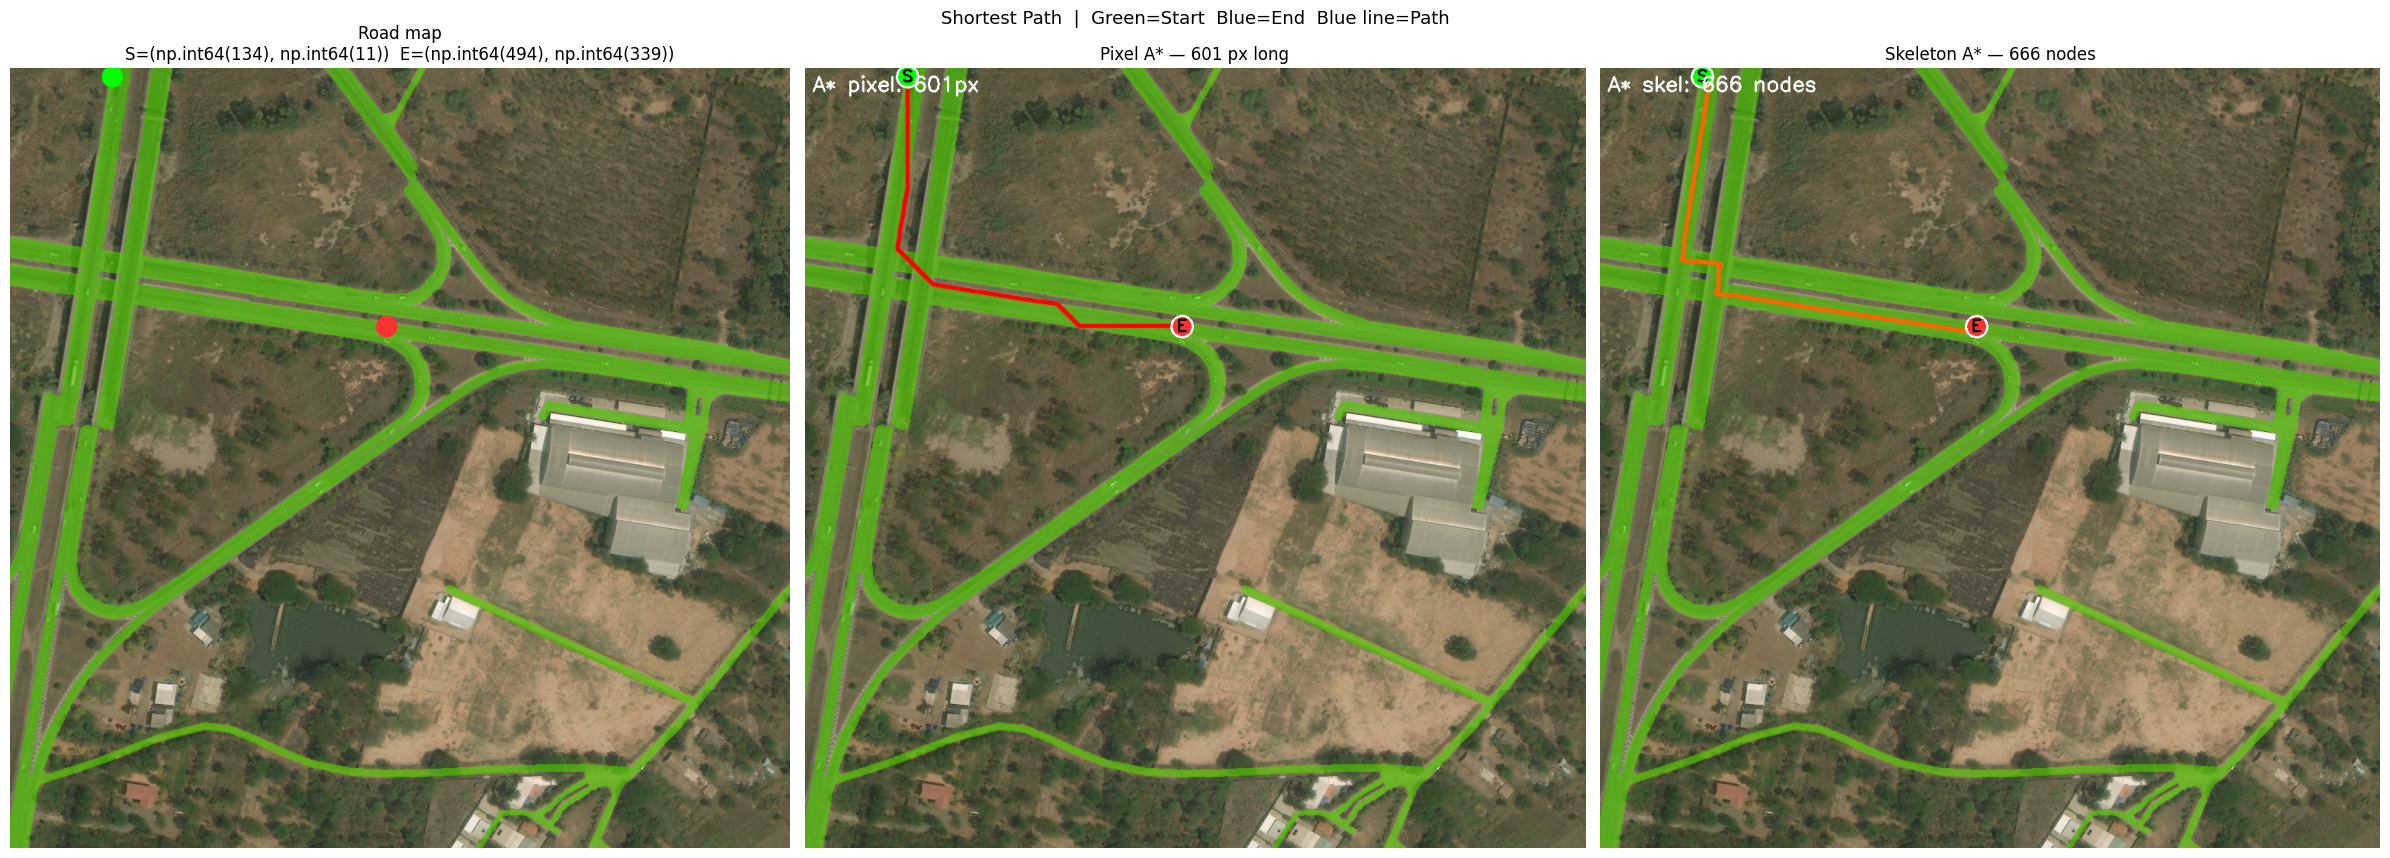

In [ ]:
# Draw and save results

def draw_result(base, path_xy, start_xy, end_xy,
                color=(0,0,255), thick=3, label=""):
    out = base.copy()
    if len(path_xy)>1:
        pts = np.array(path_xy, np.int32)
        for i in range(len(pts)-1):
            cv2.line(out,tuple(pts[i]),tuple(pts[i+1]),color,thick,cv2.LINE_AA)
    sx,sy = int(start_xy[0]),int(start_xy[1])
    ex,ey = int(end_xy[0]),  int(end_xy[1])
    cv2.circle(out,(sx,sy),14,(0,255,0),-1);   cv2.circle(out,(sx,sy),14,(255,255,255),2)
    cv2.circle(out,(ex,ey),14,(50,50,255),-1); cv2.circle(out,(ex,ey),14,(255,255,255),2)
    cv2.putText(out,"S",(sx-7,sy+6),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,0,0),2)
    cv2.putText(out,"E",(ex-7,ey+6),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,0,0),2)
    if label:
        cv2.putText(out,label,(10,30),cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,(255,255,255),2)
    return out
 
# Base overlay
ov = img.copy()
ov[binary>0] = (ov[binary>0].astype(np.float32)*0.35 +
                np.array([0,200,80],np.float32)*0.65).astype(np.uint8)
 
fig, axes = plt.subplots(1,3,figsize=(24,9))
 
# Base with points only
base_pts = ov.copy()
cv2.circle(base_pts,start_s,14,(0,255,0),-1)
cv2.circle(base_pts,end_s,  14,(50,50,255),-1)
axes[0].imshow(cv2.cvtColor(base_pts,cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Road map\nS={start_s}  E={end_s}")
axes[0].axis("off")
 
# Pixel A* result
if path:
    r1 = draw_result(ov, path, start_s, end_s,
                     color=(0,0,255), thick=3,
                     label=f"A* pixel: {len(path)}px")
    #cv2.imwrite(f"{OUTPUT_DIR}/path_astar_pixel.jpg", r1)
    axes[1].imshow(cv2.cvtColor(r1,cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Pixel A* — {len(path)} px long")
else:
    axes[1].imshow(cv2.cvtColor(ov,cv2.COLOR_BGR2RGB))
    axes[1].set_title("Pixel A* — no path")
axes[1].axis("off")
 
# Skeleton A* result
if path_skel:
    r2 = draw_result(ov, path_skel, start_s, end_s,
                     color=(0,100,255), thick=3,
                     label=f"A* skel: {len(path_skel)} nodes")
    #cv2.imwrite(f"{OUTPUT_DIR}/path_astar_skel.jpg", r2)
    axes[2].imshow(cv2.cvtColor(r2,cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Skeleton A* — {len(path_skel)} nodes")
else:
    axes[2].imshow(cv2.cvtColor(ov,cv2.COLOR_BGR2RGB))
    axes[2].set_title("Skeleton A* — no path")
axes[2].axis("off")
 
plt.suptitle("Shortest Path  |  Green=Start  Blue=End  Blue line=Path",
             fontsize=13)
plt.tight_layout()
#plt.savefig(f"{OUTPUT_DIR}/shortest_path_final.jpg",dpi=150,bbox_inches='tight')
plt.show()
#print(f"\n✓ Saved to {OUTPUT_DIR}")
 

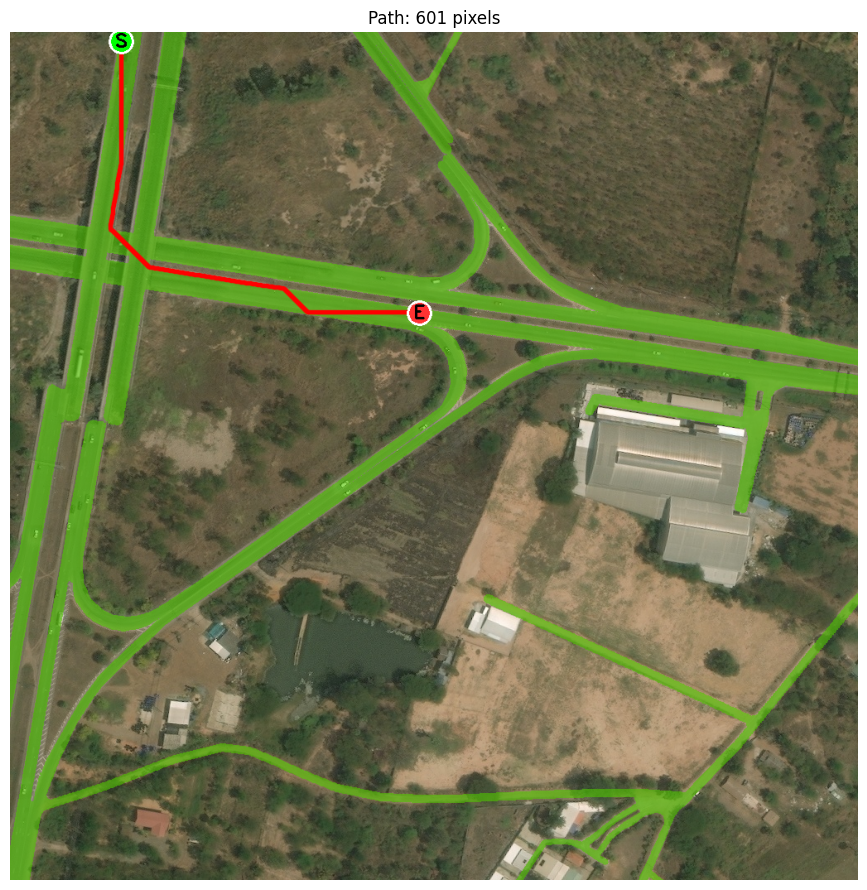

Path length: 601 px 


In [ ]:
# One-call convenience function


def find_path(mask_path, image_path, start_xy, end_xy):
              #,out_path="output/path_result.jpg"):
    """
    One-liner interface.
    start_xy, end_xy : (x, y) pixel coordinates.
    Returns path as list of (x,y) tuples.
    """
    msk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    im  = cv2.imread(image_path)
    if im.shape[:2] != msk.shape[:2]:
        im = cv2.resize(im,(msk.shape[1],msk.shape[0]))
    H2,W2 = msk.shape
    bn    = (msk>127).astype(np.uint8)

    # Re-import snap/astar using module-level functions
    import importlib, sys
    ss = Go_to_road(start_xy, bn)
    es = Go_to_road(end_xy,   bn)
    p  = astar(bn, ss, es)

    ov2 = im.copy()
    ov2[bn>0] = (ov2[bn>0].astype(np.float32)*0.4+
                 np.array([0,200,80],np.float32)*0.6).astype(np.uint8)
    res = draw_result(ov2, p, ss, es)
    #cv2.imwrite(out_path, res)
    plt.figure(figsize=(14,9))
    plt.imshow(cv2.cvtColor(res,cv2.COLOR_BGR2RGB))
    plt.title(f"Path: {len(p)} pixels"); plt.axis("off")
    plt.tight_layout(); plt.show()
    print(f"Path length: {len(p)} px ") # saved: {out_path}")
    return p

# Example:
path = find_path(MASK_PATH, IMAGE_PATH, START_POINT, END_POINT)

In [ ]:
"""
 During stitching, every fragment has a homography H_to_anchor.
  Use that same H to transform fragment pixel → stitched map pixel.
  Then run A* normally
"""

'\nDuring stitching, every fragment has a homography H_to_anchor.\n Use that same H to transform fragment pixel → stitched map pixel.\n Then run A* normally\n '

In [ ]:
def save_homographies(fragments, H_refined, T, out_path="output/homographies.json"):
    """
    Call this inside stitch_group() AFTER bundle adjustment,
    AFTER computing the translation matrix T.
 
    fragments  : your fragments list
    H_refined  : dict {frag_idx: 3x3 H matrix relative to anchor}
    T          : 3x3 translation matrix (shifts canvas to positive coords)
    out_path   : where to save
 
    The combined matrix T @ H_refined[i] is what transforms
    a pixel from fragment i → stitched map coordinates.
    """
    data = {}
    for idx, H in H_refined.items():
        # Full transform = translation @ homography
        H_full = T @ H
        data[fragments[idx]["file"]] = {
            "H_full": H_full.tolist(),      # fragment → stitched map
            "H_inv":  np.linalg.inv(H_full).tolist()  # stitched map → fragment
        }
    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"✓ Homographies saved: {out_path}")
    return data
 

In [ ]:
# let me send u my files , go through it , say whast wrong , what can be improved , rate it , ( road seg file has both classical and unet but i g i will use unet in final ) is it selection level if not how ill i imorive it and at last how to implement this points change , ( tryy is the name of img stitching file and ml is name of path_finding file i will change it latter )